-----------
Initializing structure...
time for choose_chunkdivision = 0.0772599 s
Working in 2D dimensions.
Computational cell is 12 x 11 x 0 with resolution 64
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.75,0)
          size (12,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.75,0)
          size (12,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     prism, center = (3.16205,4.68375e-17,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 256 vertices:
          (2.37049,-2.77548,0)
          (2.40803,-2.74297,0)
          (2.44512,-2.70996,0)
          (2.48176,-2.67644,0)
          (2.51795,-2.64243,0)
          (2.55366,-2.60793,0)
          (2.58891,-2.57295,0)
          (2.62367,-2.53

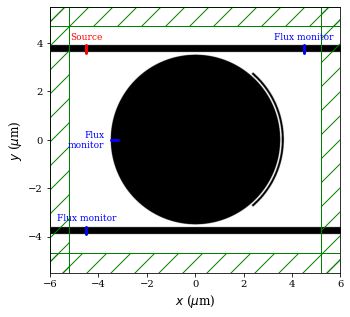

In [14]:
import meep as mp
import matplotlib.pyplot as plt
import numpy as np
import math
import time
from meep.materials import Au

c0 = 299792458  # m/s
um_scale = 1e-6  # 1 µm in m

# -----------------------------
# Simulation parameters
# -----------------------------

# Materials
sigma_meep = 0.0008
gaas = mp.Medium(epsilon=12, D_conductivity=2*math.pi*1*sigma_meep/3.4)
air = mp.Medium(epsilon=1)

# Disk and waveguide geometry
disk_radius = 3.5
wg_length = 12
wg_width = 0.3
tuner_width = 0.1
gap = 0.1  # distance between disk and waveguides
gap_tune = 0.1  # distance for curved tuner

# Simulation cell size
cell_x = wg_length 
cell_y = 2*(disk_radius + gap + wg_width/2) + 3.5
cell = mp.Vector3(cell_x, cell_y, 0)

# PML layers
pml_layers = [mp.PML(0.8)]

# -----------------------------
# Curved tuner helper function
# -----------------------------
def arc_prism(radius, width, angle_start, angle_end, npoints=64, material=gaas):
    r_in = radius - width/2
    r_out = radius + width/2
    outer = [mp.Vector3(r_out*np.cos(a), r_out*np.sin(a)) 
             for a in np.linspace(angle_start, angle_end, npoints)]
    inner = [mp.Vector3(r_in*np.cos(a), r_in*np.sin(a)) 
             for a in np.linspace(angle_end, angle_start, npoints)]
    vertices = outer + inner
    return mp.Prism(vertices=vertices, height=mp.inf, material=material)

# -----------------------------
# Geometry
# -----------------------------
geometry = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, material=gaas, center=mp.Vector3()),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius+gap+wg_width/2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius-gap-wg_width/2),
             material=gaas),
]

geometry_tuned = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, material=gaas, center=mp.Vector3()),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, disk_radius+gap+wg_width/2),
             material=gaas),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
             center=mp.Vector3(0, -disk_radius-gap-wg_width/2),
             material=gaas),
    arc_prism(radius=disk_radius+gap_tune,
              width=tuner_width,
              angle_start=-0.55/2*np.pi,
              angle_end=0.55/2*np.pi,
              npoints=128,
              material=gaas)
]

# -----------------------------
# Source and flux monitor positions
# -----------------------------
source_x = -wg_length/2 + 1.5
source_y = disk_radius + gap + wg_width/2

flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1.5,
                                                  disk_radius + gap + wg_width/2),
                                size=mp.Vector3(0, wg_width, 0))
flux_region_drop = mp.FluxRegion(center=mp.Vector3(-wg_length/2 + 1.5,
                                                   -disk_radius - gap - wg_width/2),
                                 size=mp.Vector3(0, wg_width, 0))

# -----------------------------
# Build simulation for plotting
# -----------------------------
resolution = 64
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry_tuned,
                    boundary_layers=pml_layers,
                    resolution=resolution)

# -----------------------------
# Plot geometry
# -----------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
})

fig, ax = plt.subplots(figsize=(5, 5))
sim.plot2D(ax=ax,
           plot_sources_flag=False,
           plot_monitors_flag=False)

# Source
ax.plot([source_x, source_x],
        [source_y - wg_width/2, source_y + wg_width/2],
        color='red', linewidth=3, solid_capstyle='round')
ax.text(source_x, source_y + 0.4, 'Source', color='red', ha='center', fontsize=9)

# Bus flux monitor
bus_x = wg_length/2 - 1.5
bus_y = disk_radius + gap + wg_width/2
ax.plot([bus_x, bus_x],
        [bus_y - wg_width/2, bus_y + wg_width/2],
        color='blue', linewidth=3, solid_capstyle='round')
ax.text(bus_x, bus_y + 0.4, 'Flux monitor', color='blue', ha='center', fontsize=9)

# Drop flux monitor
drop_x = -wg_length/2 + 1.5
drop_y = -disk_radius - gap - wg_width/2
ax.plot([drop_x, drop_x],
        [drop_y - wg_width/2, drop_y + wg_width/2],
        color='blue', linewidth=3, solid_capstyle='round')
ax.text(drop_x, drop_y + 0.4, 'Flux monitor', color='blue', ha='center', fontsize=9)

# Disk flux monitor (inside disk, left edge)
disk_mon_x = -disk_radius + 0.15
disk_mon_size = 0.3
ax.plot([disk_mon_x - disk_mon_size/2, disk_mon_x + disk_mon_size/2],
        [0, 0],
        color='blue', linewidth=3, solid_capstyle='round')
ax.text(disk_mon_x - 0.4, 0, 'Flux\nmonitor', color='blue', ha='right', va='center', fontsize=9)

ax.set_xlabel(r'$x$ ($\mu$m)')
ax.set_ylabel(r'$y$ ($\mu$m)')
ax.set_aspect('equal')
fig.tight_layout()
fig.savefig('/home/jonah/Desktop/thesis/images/meep_setup_disk_resonator.png', dpi=300, bbox_inches='tight')
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.16503 s
Working in 2D dimensions.
Computational cell is 12 x 10.8333 x 0 with resolution 48
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (8.95984,8.95984,8.95984)
     block, center = (0,3.67,0)
          size (12,0.3,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (8.95984,8.95984,8.95984)
     prism, center = (2.96638e-16,-1.77884,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 512 vertices:
          (-3.41239,1.10875,0)
          (-3.42841,1.05818,0)
          (-3.44368,1.00739,0)
          (-3.45819,0.956366,0)
          (-3.47195,0.905138,0)
          (-3.48496,0.853711,0)
          (-3.4972,0.802099,0)
          (-3.50867,0.75031,0)
          (-3.51938,0.698358,0)
          (-3.52932,0.646253,0)
          (-3.53849,0.594007,0)
          (-3.54688,0.54

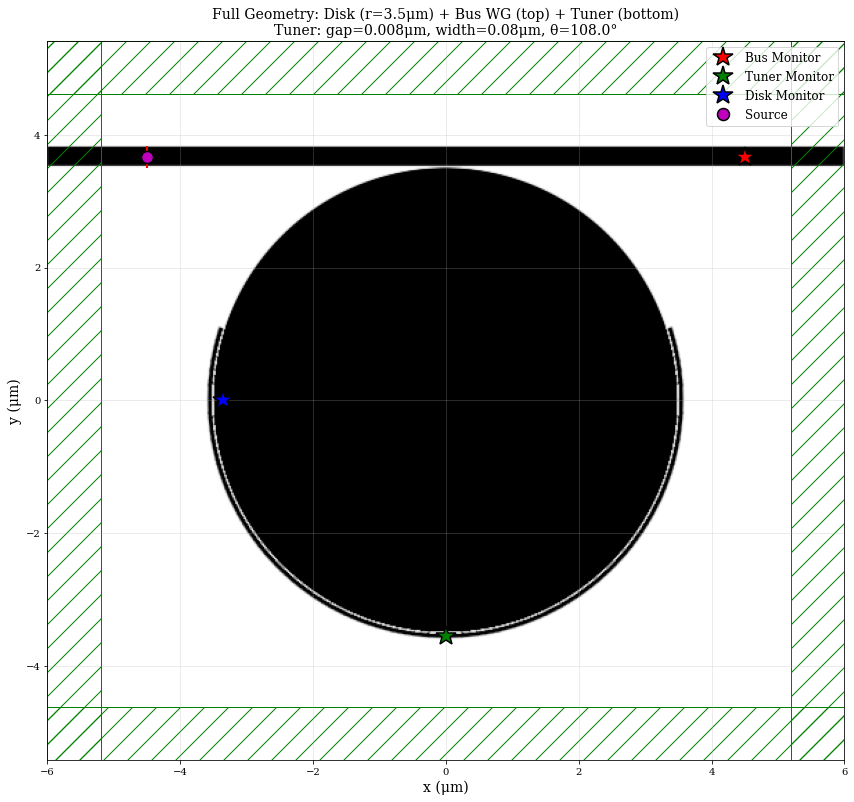

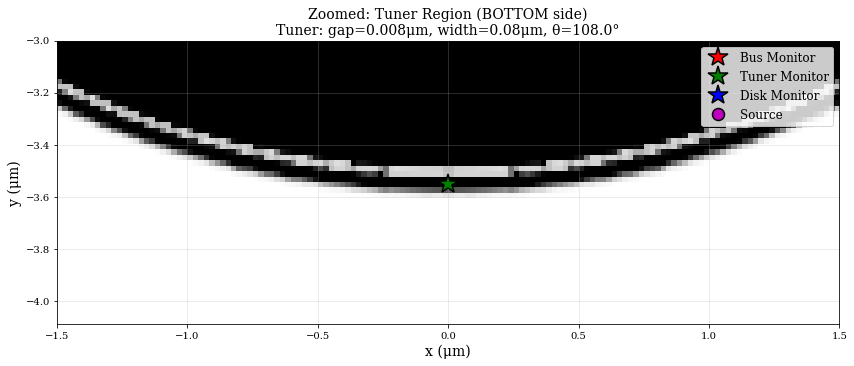

In [7]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Simulation parameters
# -----------------------------------
c0 = 299792458  # m/s
um_scale = 1e-6  # 1 µm

sigma_meep = 0.00
n_eff = 2.9933
gaas = mp.Medium(epsilon= n_eff**2, D_conductivity=2*np.pi*1*sigma_meep/n_eff)

disk_radius = 3.5
wg_length = 12
wg_width = 0.3
gap = 0.02
gap_tune = 0.008  # Example value

cell_x = wg_length
cell_y = 2 * (disk_radius + gap + wg_width / 2) + 3.5
cell = mp.Vector3(cell_x, cell_y, 0)
pml_layers = [mp.PML(0.8)]

f_thz = 318
fcen = f_thz * um_scale * 1e12 / c0
df_thz = 20
fwidth = df_thz * um_scale * 1e12 / c0
resolution = 48
theta = 1.2/2*np.pi  # tuner angle extent
tw = 0.08  # tuner width

src_center = mp.Vector3(-wg_length / 2 + 1.5, disk_radius + gap + wg_width / 2)
sources = [mp.Source(mp.GaussianSource(fcen, fwidth=fwidth),
                     component=mp.Hz,
                     center=src_center,
                     size=mp.Vector3(0, wg_width, 0))]

# -----------------------------------
# Helper for curved tuner
# -----------------------------------
def arc_prism(radius, width, angle_start, angle_end, npoints, material=gaas):
    r_in = radius
    r_out = radius + width
    outer = [mp.Vector3(r_out*np.cos(a), r_out*np.sin(a)) for a in np.linspace(angle_start, angle_end, npoints)]
    inner = [mp.Vector3(r_in*np.cos(a), r_in*np.sin(a)) for a in np.linspace(angle_end, angle_start, npoints)]
    vertices = outer + inner
    return mp.Prism(vertices=vertices, height=mp.inf, material=material)

# -----------------------------------
# Geometry with tuner on BOTTOM side (opposite from bus on top)
# -----------------------------------
geometry = [
    mp.Cylinder(radius=disk_radius, height=mp.inf, material=gaas, center=mp.Vector3()),
    mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
            center=mp.Vector3(0, disk_radius + gap + wg_width / 2),
            material=gaas),
    # Tuner centered at 3π/2 (270° or -π/2), which is BOTTOM (negative y)
    arc_prism(radius=disk_radius + gap_tune,
            width=tw,
            angle_start=-np.pi/2 - theta,
            angle_end=-np.pi/2 + theta,
            npoints=256,
            material=gaas)
]

# Create simulation (no run needed for visualization)
sim = mp.Simulation(
    cell_size=cell,
    geometry=geometry,
    sources=sources,
    boundary_layers=pml_layers,
    resolution=resolution
)

# -----------------------------------
# Plot full geometry
# -----------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
sim.plot2D(ax=ax)

# Add monitor positions
# Bus monitor (top right)
ax.plot(wg_length/2 - 1.5, disk_radius + gap + wg_width/2, 'r*', 
        markersize=20, label='Bus Monitor', markeredgecolor='black', markeredgewidth=1.5)

# Tuner monitor (BOTTOM side at y < 0)
tuner_monitor_y = -(disk_radius + gap_tune + tw/2)
ax.plot(0, tuner_monitor_y, 'g*', 
        markersize=20, label='Tuner Monitor', markeredgecolor='black', markeredgewidth=1.5)

# Disk monitor (left side)
ax.plot(-disk_radius+0.15, 0, 'b*', 
        markersize=20, label='Disk Monitor', markeredgecolor='black', markeredgewidth=1.5)

# Source (top left)
ax.plot(src_center.x, src_center.y, 'mo', 
        markersize=12, label='Source', markeredgecolor='black', markeredgewidth=1.5)

ax.set_xlabel('x (μm)', fontsize=14)
ax.set_ylabel('y (μm)', fontsize=14)
ax.set_title(f'Full Geometry: Disk (r={disk_radius}μm) + Bus WG (top) + Tuner (bottom)\n' + 
             f'Tuner: gap={gap_tune}μm, width={tw}μm, θ={theta*180/np.pi:.1f}°', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------
# Plot zoomed view of tuner region (BOTTOM side)
# -----------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
sim.plot2D(ax=ax)

# Add monitor positions
ax.plot(wg_length/2 - 1.5, disk_radius + gap + wg_width/2, 'r*', 
        markersize=20, label='Bus Monitor', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(0, tuner_monitor_y, 'g*', 
        markersize=20, label='Tuner Monitor', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(-disk_radius+0.15, 0, 'b*', 
        markersize=20, label='Disk Monitor', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(src_center.x, src_center.y, 'mo', 
        markersize=12, label='Source', markeredgecolor='black', markeredgewidth=1.5)

# Zoom in on BOTTOM tuner region
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-(disk_radius + gap_tune + tw + 0.5), -disk_radius + 0.5])
ax.set_xlabel('x (μm)', fontsize=14)
ax.set_ylabel('y (μm)', fontsize=14)
ax.set_title(f'Zoomed: Tuner Region (BOTTOM side)\n' + 
             f'Tuner: gap={gap_tune}μm, width={tw}μm, θ={theta*180/np.pi:.1f}°', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Run only tuned setup - first gaussian spectrum than single (resonance) frequency 

In [ ]:
# -----------------------------
# Source (broadband run)
# -----------------------------
source_x = -wg_length/2 + 1.5
source_y = disk_radius + gap + wg_width/2

f_thz = 322  # target resonance frequency in THz
f_cen = f_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)
# bandwidth for Gaussian source
df_thz = 20  # n THz
df = df_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)


#fmin = 0.3
#fmax = 0.35
#df = fmax - fmin

nfreq = 4000
resolution = 40  # pixels/um
field_decay = 1e-4  # field decay for stopping condition


sources = [mp.Source(mp.GaussianSource(frequency=f_cen, fwidth=df),
                     component=mp.Hz,
                     center=mp.Vector3(source_x, source_y),
                     size=mp.Vector3(0, wg_width, 0))]

# -----------------------------
# Flux monitors
# -----------------------------
flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1.5,
                                                  disk_radius + gap + wg_width/2),
                                size=mp.Vector3(0, wg_width, 0))

# Drop port moved to left side of lower waveguide (same side as source, opposite waveguide)
flux_region_drop = mp.FluxRegion(center=mp.Vector3(-wg_length/2 + 1.5,
                                                   -disk_radius - gap - wg_width/2),
                                 size=mp.Vector3(0, wg_width, 0))


# -----------------------------
# First Simulation (spectra)
# -----------------------------
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    sources=sources,
                    boundary_layers=pml_layers,
                    resolution=resolution)

trans_flux_bus = sim.add_flux(f_cen, df, nfreq, flux_region_bus)
trans_flux_drop = sim.add_flux(f_cen, df, nfreq, flux_region_drop)

sim.run(until_after_sources=mp.stop_when_fields_decayed(100, mp.Hz, mp.Vector3(), field_decay))

frequencies = np.array(mp.get_flux_freqs(trans_flux_bus))
flux_bus = np.array(mp.get_fluxes(trans_flux_bus))
flux_drop = np.array(mp.get_fluxes(trans_flux_drop))

# -----------------------------
# Find resonance from max |flux_drop|
# -----------------------------
res_freq = frequencies[np.argmax(np.abs(flux_drop))]
print(f"Resonance frequency (max |drop port|): {res_freq:.6f} 1/um")

## Conversion: Meep freq (1/um) → THz
freq_thz = frequencies * c0 / um_scale / 1e12
res_freq_thz = res_freq * c0 / um_scale / 1e12

# Plot
plt.figure(figsize=(8,5))
plt.plot(freq_thz, flux_bus, label='Bus (top, right)')
plt.plot(freq_thz, flux_drop, label='Drop (bottom, left)')
plt.axvline(res_freq_thz, color='r', ls='--', label=f'Peak (drop) = {res_freq_thz:.2f} THz')
plt.xlabel('Frequency (THz)')
plt.ylabel('Flux')
plt.title('Broadband transmission spectra (Gaussian source)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Second Simulation (single freq)
# -----------------------------
sources_res = [mp.Source(mp.ContinuousSource(frequency=res_freq),
                         component=mp.Hz,
                         center=mp.Vector3(source_x, source_y),
                         size=mp.Vector3(0, wg_width, 0))]

sim_res = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        sources=sources_res,
                        boundary_layers=pml_layers,
                        resolution=resolution)

ez_data = []
def store_fields(sim):
    ez_data.append(sim.get_array(center=mp.Vector3(),
                                 
                                 size=cell,
                                 component=mp.Hz))

sim_res.run(mp.at_every(20, store_fields), until=1000)

# -----------------------------
# Plot Hz snapshots
# -----------------------------
for i, field in enumerate(ez_data):
    if i % 10 == 0:
        plt.figure(figsize=(12,6))
        plt.imshow(np.rot90(field), cmap="RdBu", origin="lower",
                   extent=[-cell_x/2, cell_x/2, -cell_y/2, cell_y/2])
        plt.colorbar(label="Hz field")
        plt.title(f"Hz snapshot {i*20} time units at res_freq={res_freq:.4f}")
        plt.xlabel("x (µm)")
        plt.ylabel("y (µm)")
        plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.00129485 s
Working in 2D dimensions.
Computational cell is 31 x 17.425 x 0 with resolution 40
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (30,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (30,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)


          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 2.02706 s
-----------
on time step 189 (time=2.3625), 0.0212682 s/step
on time step 391 (time=4.8875), 0.0198611 s/step
on time step 584 (time=7.3), 0.0207426 s/step
on time step 768 (time=9.6), 0.0218012 s/step
on time step 925 (time=11.5625), 0.025562 s/step
on time step 1108 (time=13.85), 0.0219764 s/step
on time step 1288 (time=16.1), 0.0222925 s/step
on time step 1474 (time=18.425), 0.0215968 s/step
on time step 1656 (time=20.7), 0.0220856 s/step
on time step 1829 (time=22.8625), 0.0231924 s/step
on time step 2003 (time=25.0375), 0.0231755 s/step
on time step 2145 (time=26.8125), 0.0281989 s/step
on time step 2283 (time=28.5375), 0.0291868 s/step
on time step 2427 (time=30.3375), 0.0279683 s/step
on time step 2590 (time=32.375), 0.0246693 s/step
on time step 2765 (time=34.5625), 0.0229204 s/step
on time step 2958 (time=36.975), 0.0208003 s/step
on time step 3132 (time=39.15), 0.0231072 s/step
on tim

KeyboardInterrupt: 

## Saver Function

In [3]:
import os
import h5py
from datetime import datetime

def save_sim(params, frequencies, flux_bus, flux_drop, flux_tuner, ez_field, eps_data):
    # -----------------------------
    # Create data folder structure
    # -----------------------------
    base_dir = "data"
    os.makedirs(base_dir, exist_ok=True)

    # Use parameter-based folder name
    folder_name = f"{datetime.now().strftime('%Y%m%d_%H%M')}_sim_tuner{params['tuner_gap']}_r{params['disk_radius']}_g{params['gap']}_f{params['f_thz']}_res{params['resolution']}_decay{params['field_decay']}"
    run_dir = os.path.join(base_dir, folder_name)
    os.makedirs(run_dir, exist_ok=True)


    params_path = os.path.join(run_dir, "params.txt")
    with open(params_path, "w") as f:
        f.write("# Simulation parameters\n")
        f.write("# ----------------------\n")
        for key, value in params.items():
            f.write(f"{key} = {value}\n")

    print(f"Parameters saved to {params_path}")



    # -----------------------------
    # Save flux data
    # -----------------------------
    flux_path = os.path.join(run_dir, "flux_data.h5")

    with h5py.File(flux_path, "w") as f:
        f.create_dataset("frequency", data=frequencies)
        f.create_dataset("flux_bus", data=flux_bus)
        f.create_dataset("flux_drop", data=flux_drop)
        f.create_dataset("flux_tuner", data=flux_tuner)

    print(f"Flux data saved to {flux_path}")

    # -----------------------------
    # Save field data (Ez and epsilon)
    # -----------------------------


    ez_path = os.path.join(run_dir, "Hz_field.npy")
    eps_path = os.path.join(run_dir, "epsilon.npy")

    np.save(ez_path, ez_field)
    np.save(eps_path, eps_data)

    print(f"Hz field saved to {ez_path}")
    print(f"Epsilon field saved to {eps_path}")

### Comparison between different tuner settings and no tuner 

-----------
Initializing structure...
time for choose_chunkdivision = 0.00078392 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)


time for set_epsilon = 1.14946 s
time for set_conductivity = 0.027683 s
time for set_conductivity = 0.0273309 s
time for set_conductivity = 0.0293999 s
-----------
on time step 176 (time=2.93333), 0.0227277 s/step
on time step 359 (time=5.98333), 0.0219416 s/step
on time step 581 (time=9.68333), 0.0180735 s/step
on time step 771 (time=12.85), 0.0210729 s/step
on time step 953 (time=15.8833), 0.0220069 s/step
on time step 1126 (time=18.7667), 0.0231699 s/step
on time step 1297 (time=21.6167), 0.0234947 s/step
on time step 1462 (time=24.3667), 0.0242703 s/step
on time step 1704 (time=28.4), 0.0165421 s/step
on time step 2020 (time=33.6667), 0.0126597 s/step
on time step 2384 (time=39.7333), 0.0109933 s/step
on time step 2755 (time=45.9167), 0.0107864 s/step
on time step 3040 (time=50.6667), 0.0140606 s/step
on time step 3427 (time=57.1167), 0.0103413 s/step
on time step 3807 (time=63.45), 0.0105494 s/step
on time step 4093 (time=68.2167), 0.0140208 s/step
on time step 4461 (time=74.35), 

Hz field saved to data/20251021_1733_sim_tuner0.0_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251021_1733_sim_tuner0.0_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.0] Resonance freq = 1.075862 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00690389 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     prism, center = (2.92752,2.08167e-17,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 256 v

field decay(t = 1900.3166666666666): 1.5417206989424828e-07 / 0.0009253352047467178 = 0.00016661213050512668
run 0 finished at t = 1900.3166666666666 (114019 timesteps)
Parameters saved to data/20251021_1807_sim_tuner0.001_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251021_1807_sim_tuner0.001_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251021_1807_sim_tuner0.001_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251021_1807_sim_tuner0.001_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.001] Resonance freq = 1.068186 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00311208 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axe

field decay(t = 1700.2833333333333): 1.1501253529234864e-07 / 0.0009241411711651602 = 0.00012445342646875092
run 0 finished at t = 1700.2833333333333 (102017 timesteps)
Parameters saved to data/20251021_1837_sim_tuner0.002_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251021_1837_sim_tuner0.002_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251021_1837_sim_tuner0.002_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251021_1837_sim_tuner0.002_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.002] Resonance freq = 1.068286 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00455594 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axe

...

field decay(t = 3000.5): 1.6175382993205422e-07 / 0.0010597132214625567 = 0.00015263924867221215
run 0 finished at t = 3000.5 (180030 timesteps)
Parameters saved to data/20251021_2329_sim_tuner0.2_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251021_2329_sim_tuner0.2_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251021_2329_sim_tuner0.2_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251021_2329_sim_tuner0.2_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.2] Resonance freq = 1.075862 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00665903 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
      

field decay(t = 2600.4333333333334): 2.051556821113414e-07 / 0.0011390436972465215 = 0.00018011221396270968
run 0 finished at t = 2600.4333333333334 (156026 timesteps)
Parameters saved to data/20251022_0015_sim_tuner0.25_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251022_0015_sim_tuner0.25_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251022_0015_sim_tuner0.25_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_0015_sim_tuner0.25_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.25] Resonance freq = 1.075828 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00590205 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0

field decay(t = 2600.4333333333334): 1.9234562700502313e-07 / 0.0012158476812278826 = 0.0001581987858962511
run 0 finished at t = 2600.4333333333334 (156026 timesteps)
Parameters saved to data/20251022_0101_sim_tuner0.3_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251022_0101_sim_tuner0.3_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251022_0101_sim_tuner0.3_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_0101_sim_tuner0.3_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.3] Resonance freq = 1.075828 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00457597 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), 

field decay(t = 2400.4): 2.4749889190862036e-07 / 0.0012949750886329468 = 0.0001911225119935666
run 0 finished at t = 2400.4 (144024 timesteps)
Parameters saved to data/20251022_0143_sim_tuner0.35_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251022_0143_sim_tuner0.35_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251022_0143_sim_tuner0.35_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_0143_sim_tuner0.35_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.35] Resonance freq = 1.075862 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00332785 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
  

field decay(t = 2600.4333333333334): 2.2096045924362657e-07 / 0.0012566597203183469 = 0.0001758315760989388
run 0 finished at t = 2600.4333333333334 (156026 timesteps)
Parameters saved to data/20251022_0229_sim_tuner0.4_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251022_0229_sim_tuner0.4_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251022_0229_sim_tuner0.4_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_0229_sim_tuner0.4_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=0.4] Resonance freq = 1.075895 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00448203 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), 

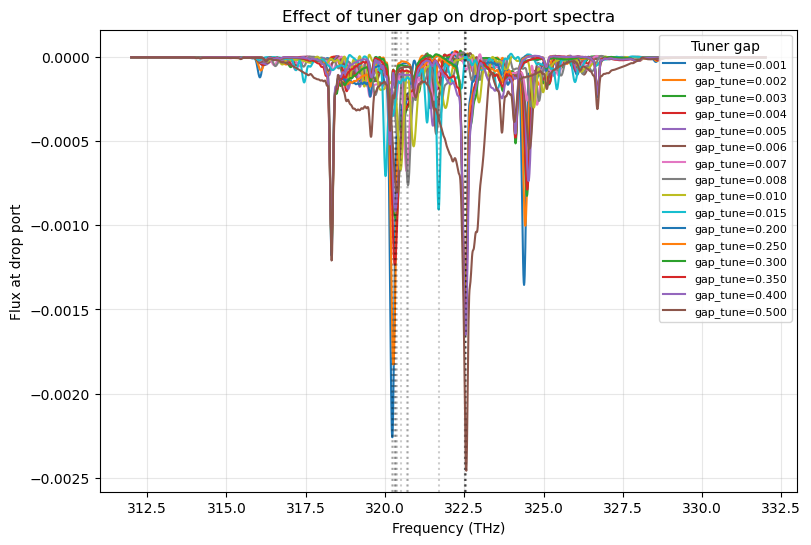

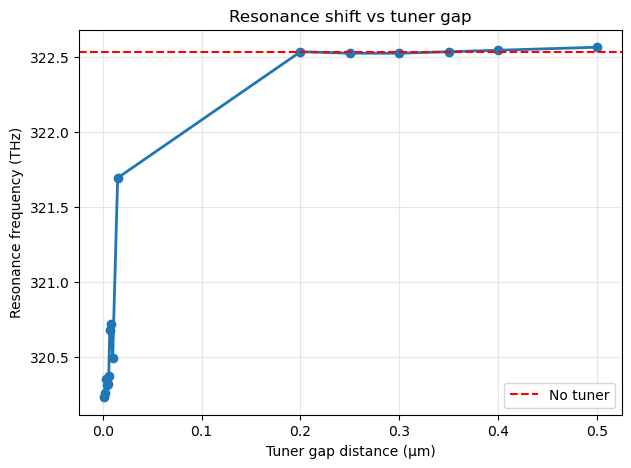

In [ ]:
# -----------------------------
# Source (broadband run)
# -----------------------------
source_x = -wg_length/2 + 4
source_y = disk_radius + gap + wg_width/2

f_thz = 322  # target resonance frequency in THz
f_cen = f_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)
# bandwidth for Gaussian source
df_thz = 20  # n THz
df = df_thz * um_scale * 1e12 / c0  # convert to Meep freq (1/um)


#fmin = 0.3
#fmax = 0.35
#df = fmax - fmin

nfreq = 30000
resolution = 24  # pixels/um
field_decay = 1e-4  # field decay for stopping condition


sources = [mp.Source(mp.GaussianSource(frequency=f_cen, fwidth=df),
                     component=mp.Hz,
                     center=mp.Vector3(source_x, source_y),
                     size=mp.Vector3(0, wg_width, 0))]

# -----------------------------
# Flux monitors
# -----------------------------
flux_region_bus = mp.FluxRegion(center=mp.Vector3(wg_length/2 - 1.5, disk_radius + gap + wg_width/2),
                                size=mp.Vector3(0, wg_width, 0))

# Drop port moved to left side of lower waveguide (same side as source, opposite waveguide)
flux_region_drop = mp.FluxRegion(center=mp.Vector3(-wg_length/2 + 1.5, -disk_radius - gap - wg_width/2),
                                 size=mp.Vector3(0, wg_width, 0))

flux_region_tuner = mp.FluxRegion(center=mp.Vector3(disk_radius + gap_tune, 0),
                                  size=mp.Vector3(0, tuner_width, 0))

# -----------------------------
# Helper: build tuned geometry
# -----------------------------
def make_geometry_tuned(gap_tune_val):
    return [
        mp.Cylinder(radius=disk_radius, height=mp.inf, material=gaas, center=mp.Vector3()),
        mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
                 center=mp.Vector3(0, disk_radius+gap+wg_width/2),
                 material=gaas),
        mp.Block(size=mp.Vector3(wg_length, wg_width, mp.inf),
                 center=mp.Vector3(0, -disk_radius-gap-wg_width/2),
                 material=gaas),
        arc_prism(radius=disk_radius+gap_tune_val+tuner_width/2,
                  width=tuner_width,
                  angle_start=-np.pi/3,
                  angle_end=np.pi/3,
                  npoints=128,
                  material=gaas)
    ]

# -----------------------------
# Run a single simulation
# -----------------------------
def run_sim(geometry, gap_tune):
    sim = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        sources=sources,
                        boundary_layers=pml_layers,
                        resolution=resolution)

    trans_flux_bus = sim.add_flux(f_cen, df, nfreq, flux_region_bus)
    trans_flux_drop = sim.add_flux(f_cen, df, nfreq, flux_region_drop)
    trans_flux_tuner = sim.add_flux(f_cen, df, nfreq, flux_region_tuner)

    start_time = time.time()
    
    sim.run(until_after_sources=mp.stop_when_fields_decayed(100, mp.Hz, mp.Vector3(), field_decay))

    runtime = time.time() - start_time

    params = {
        "disk_radius": disk_radius,
        "gap": gap,
        "wg_length": wg_length,
        "wg_width": wg_width,
        "cell_size": (cell_x, cell_y),
        "f_thz": f_thz,
        "df_thz": df_thz,
        "n_freq_points": nfreq,
        "resolution": resolution,
        "field_decay": field_decay,
        "runtime_seconds": runtime,
        "runtime_minutes": runtime/60,
        "tuner_width": tuner_width,
        "tuner_gap": gap_tune,
    }

    freqs = np.array(mp.get_flux_freqs(trans_flux_bus))
    flux_bus = np.array(mp.get_fluxes(trans_flux_bus))
    flux_drop = np.array(mp.get_fluxes(trans_flux_drop))
    flux_tuner = np.array(mp.get_fluxes(trans_flux_tuner))

    # Get Hz and epsilon arrays from the final simulation state
    ez_field = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Hz)
    eps_data = sim.get_epsilon()

    save_sim(params, freqs, flux_bus, flux_drop, flux_tuner, ez_field, eps_data)

    res_freq = freqs[np.argmax(np.abs(flux_drop))]
    print(f"[gap_tune={gap_tune}] Resonance freq = {res_freq:.6f} 1/um")

    return freqs, flux_bus, flux_drop, flux_tuner, res_freq


# -----------------------------
# Run baseline (no tuner)
# -----------------------------
result_no_tuner = []
freqs, bus, drop, tuner, res = run_sim(geometry, 0.0)
result_no_tuner.append(("no tuner", 0.0, freqs, bus, drop, tuner, res))

# -----------------------------
# Sweep gap_tune values
# -----------------------------
results = []
gap_tune_values = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.05]   # µm
for g in gap_tune_values:
    geom = make_geometry_tuned(g)
    freqs, bus, drop, tuner, res = run_sim(geom, g)
    results.append((f"gap_tune={g:.3f}", g, freqs, bus, drop, tuner, res))


# -----------------------------
# Convert frequency → THz
# -----------------------------
c0 = 299792458
um_scale = 1e-6
freqs_thz = results[0][2] * c0 / um_scale / 1e12

# -----------------------------
# Plot 1: Spectra
# -----------------------------
plt.figure(figsize=(9,6))
for label, g, freqs, bus, drop, tuner, res in results:
    res_thz = res * c0 / um_scale / 1e12
    plt.plot(freqs_thz, drop, label=label)
    plt.axvline(res_thz, color='k', ls=':', alpha=0.2)

plt.xlabel('Frequency (THz)')
plt.ylabel('Flux at drop port')
plt.title('Effect of tuner gap on drop-port spectra')
plt.legend(loc='upper right', fontsize=8, title='Tuner gap')
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Plot 2: Resonance frequency vs tuner distance
# -----------------------------
res_freqs_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, _, res) in results]
res_freq_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, _, res) in result_no_tuner]
gaps = [g for (_, g, _, _, _, _, _) in results]

plt.figure(figsize=(7,5))
plt.plot(gaps, res_freqs_thz, "o-", lw=2)
plt.axhline(res_freq_thz, color='r', ls='--', label='No tuner')
plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Resonance shift vs tuner gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


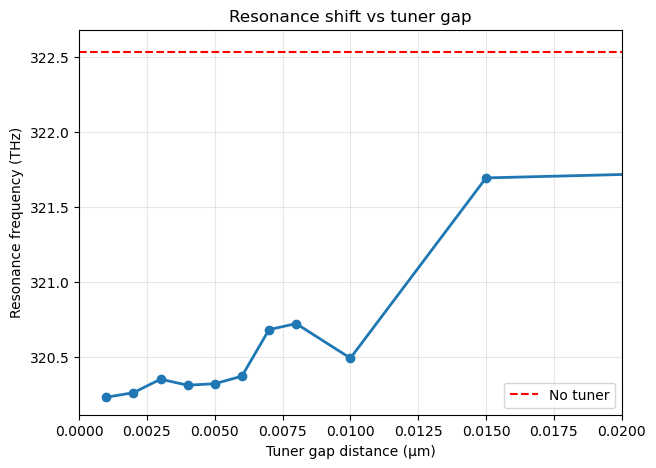

In [6]:
# -----------------------------
# Plot 2: Resonance frequency vs tuner distance (zoomed x-axis)
# -----------------------------
res_freqs_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, _, res) in results]
res_freq_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, _, res) in result_no_tuner]
gaps = [g for (_, g, _, _, _, _, _) in results]

plt.figure(figsize=(7,5))
plt.plot(gaps, res_freqs_thz, "o-", lw=2)
plt.axhline(res_freq_thz, color='r', ls='--', label='No tuner')
plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Resonance shift vs tuner gap")
plt.xlim(0, 0.02)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

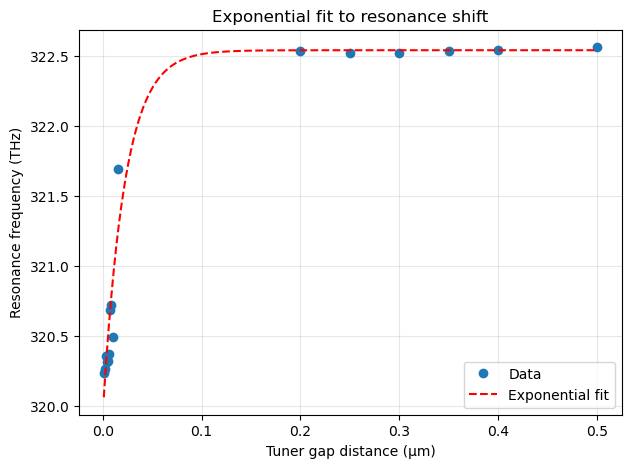

Fit parameters: a=-2.5963, b=-45.2166, c=322.5438


In [ ]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# Exponential fit function: y = a * exp(b * x) + c
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

# Use gaps_filtered and res_filtered if available, else use gaps and res_freqs_thz
if "gaps_filtered" in locals() and "res_filtered" in locals():
    xdata = np.array(gaps_filtered)
    ydata = np.array(res_filtered)
else:
    xdata = np.array(gaps)
    ydata = np.array(res_freqs_thz)

# Initial guess for parameters
p0 = [ydata.max() - ydata.min(), -10, ydata.min()]

# Fit
popt, pcov = curve_fit(exp_func, xdata, ydata, p0=p0)

# Generate fit curve
xfit = np.linspace(xdata.min(), xdata.max(), 200)
yfit = exp_func(xfit, *popt)

# Calculate residuals and chi-square
residuals = ydata - exp_func(xdata, *popt)
chisq = np.sum(residuals**2)               # if no uncertainties given
ndof = len(ydata) - len(popt)              # degrees of freedom
chisq_red = chisq / ndof                   # reduced chi-square

# Plot data and fit
plt.figure(figsize=(7,5))
plt.plot(xdata, ydata, "o", label="Data")
plt.plot(xfit, yfit, "r--", label="Exponential fit")
plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Exponential fit to resonance shift")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Fit parameters: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}")
print(f"Chi-square: {chisq:.4f}")
print(f"Reduced chi-square: {chisq_red:.4f}")


     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     prism, center = (3.05035,-1.75207e-16,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 256 vertices:
          (1.875,-3.2476,0)
          (1.9283,-3.21623,0)
          (1.98107,-3.184,0)
          (2.03331,-3.1509,0)


          (2.08499,-3.11694,0)
          (2.13611,-3.08213,0)
          (2.18665,-3.04649,0)
          (2.23659,-3.01001,0)
          (2.28592,-2.97272,0)
          (2.33463,-2.93462,0)
          (2.38271,-2.89572,0)
          (2.43014,-2.85604,0)
          (2.4769,-2.81557,0)
          (2.523,-2.77434,0)
          (2.5684,-2.73236,0)
          (2.61311,-2.68964,0)
          (2.65711,-2.64618,0)
          (2.70039,-2.602,0)
          (2.74293,-2.55712,0)
          (2.78472,-2.51154,0)
          (2.82576,-2.46527,0)
          (2.86603,-2.41834,0)
          (2.90552,-2.37075,0)
          (2.94422,-2.32251,0)
          (2.98212,-2.27365,0)
          (3.01921,-2.22416,0)
          (3.05547,-2.17407,0)
          (3.09091,-2.12339,0)
          (3.12551,-2.07213,0)
          (3.15925,-2.0203,0)
          (3.19214,-1.96793,0)
          (3.22416,-1.91502,0)
          (3.2553,-1.86159,0)
          (3.28555,-1.80766,0)
          (3.31492,-1.75323,0)
          (3.34338,-1.69833,0)
          (3.370

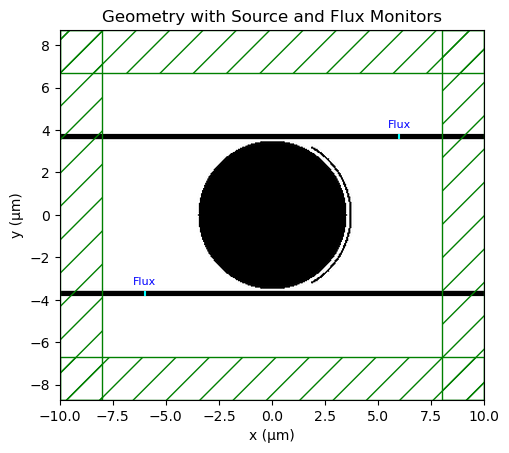

In [8]:
# -----------------------------
# Visualization (geometry + sources + monitors)
# -----------------------------
sim.plot2D()
ax = plt.gca()

# Plot source(s)
for s in sim.sources:
    ax.plot(s.center.x, s.center.y, 'ro', label='Source')
    # Draw source width (vertical line segment)
    ax.plot([s.center.x, s.center.x],
            [s.center.y - s.size.y/2, s.center.y + s.size.y/2],
            color='red', linewidth=2)
    ax.text(s.center.x, s.center.y + 0.4, 'Source', color='red', ha='center', fontsize=8)

flux_regions = [flux_region_bus, flux_region_drop]
# Plot flux regions (rectangles)
for fr in flux_regions:
    x, y = fr.center.x, fr.center.y
    sx, sy = fr.size.x, fr.size.y
    rect = plt.Rectangle((x - sx/2, y - sy/2), sx, sy,
                         linewidth=1.5, edgecolor='cyan',
                         facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y + 0.4, 'Flux', color='blue', ha='center', fontsize=8)

plt.title("Geometry with Source and Flux Monitors")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.show()

## Add more runs (different gap size)

In [11]:

print(res_freqs_thz)

[np.float64(320.2341170585292), np.float64(320.2641320660329), np.float64(320.35417708854425), np.float64(320.3141570785392), np.float64(320.3241620810404), np.float64(320.3741870935467), np.float64(320.6843421710856), np.float64(320.7243621810905), np.float64(320.49424712356176), np.float64(321.6948474237118), np.float64(322.5352676338169), np.float64(322.5252626313156), np.float64(322.5252626313156), np.float64(322.5352676338169), np.float64(322.54527263631815), np.float64(322.5652826413206)]


In [12]:

# -----------------------------
# Existing results from previous run
# -----------------------------
# Make sure you have this loaded
# results = [("no tuner", 0.0, freqs, bus, drop, res), ("gap_tune=0.05", 0.05, ...), ...]
# Example placeholder (replace with your real results):
# results = [...]

# -----------------------------
# New tuner gaps to add
# -----------------------------
new_gaps = [0.012, 0.03, 0.1]  # µm

# -----------------------------
# Run only new gaps
# -----------------------------
for g in new_gaps:
    label = f"gap_tune={g:.2f}"
    # Skip if already in results
    if any(abs(r[1]-g) < 1e-6 for r in results):
        print(f"Gap {g} µm already in results, skipping.")
        continue
    geom = make_geometry_tuned(g)
    freqs, bus, drop, res, tuner = run_sim(geom, label)
    results.append((label, g, freqs, bus, drop, res, tuner))

# -----------------------------
# Sort results by gap distance
# -----------------------------
results = sorted(results, key=lambda x: x[1])

# -----------------------------
# Plot: Drop-port spectra
# -----------------------------
c0 = 299792458
um_scale = 1e-6
freqs_thz = results[0][2] * c0 / um_scale / 1e12  # assuming all freqs arrays identical

plt.figure(figsize=(9,6))
for label, g, freqs, bus, drop, res in results:
    res_thz = res * c0 / um_scale / 1e12
    plt.plot(freqs_thz, drop, label=label)
    plt.axvline(res_thz, color='k', ls=':', alpha=0.2)

plt.xlabel('Frequency (THz)')
plt.ylabel('Flux at drop port')
plt.title('Effect of tuner gap on drop-port spectra')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Extract data
# -----------------------------
res_freqs_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, res, _) in results]
gaps = [g for (_, g, _, _, _, _, _) in results]

# Separate the "no tuner" case (g=0)
res_no_tuner = None
gaps_filtered = []
res_filtered = []
for g, res in zip(gaps, res_freqs_thz):
    if g == 0:
        res_no_tuner = res
    else:
        gaps_filtered.append(g)
        res_filtered.append(res)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(gaps_filtered, res_filtered, "o-", lw=2, label="With tuner")
if res_no_tuner is not None:
    plt.axhline(res_no_tuner, color="r", ls="--", 
                label=f"No tuner (g=0): {res_no_tuner:.2f} THz")

plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Resonance shift vs tuner gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



-----------
Initializing structure...
time for choose_chunkdivision = 0.00334597 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     prism, center = (2.93658,-3.98986e-17,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 256 vertices:
          (1.806,-3.12808,0)
          (1.85734,-3.09788,0)
          (1.90817,-3.06683,0)
          (1.95849,-3.03494,0)
          (2.00827,-3.00223,0)
          (2.0575,-2.96871,0)
          (2.10618,-2.93437,0)
          (2.15428

          (3.56776,-0.56357,0)
          (3.57657,-0.504659,0)
          (3.58441,-0.445611,0)
          (3.59127,-0.386442,0)
          (3.59715,-0.327167,0)
          (3.60206,-0.267804,0)
          (3.60598,-0.208367,0)
          (3.60893,-0.148874,0)
          (3.61089,-0.0893408,0)
          (3.61188,-0.029783,0)
          (3.61188,0.029783,0)
          (3.61089,0.0893408,0)
          (3.60893,0.148874,0)
          (3.60598,0.208367,0)
          (3.60206,0.267804,0)
          (3.59715,0.327167,0)
          (3.59127,0.386442,0)
          (3.58441,0.445611,0)
          (3.57657,0.504659,0)
          (3.56776,0.56357,0)
          (3.55798,0.622328,0)
          (3.54724,0.680917,0)
          (3.53553,0.73932,0)
          (3.52285,0.797522,0)
          (3.50922,0.855508,0)
          (3.49464,0.91326,0)
          (3.4791,0.970765,0)
          (3.46262,1.028,0)
          (3.4452,1.08497,0)
          (3.42684,1.14163,0)
          (3.40755,1.19799,0)
          (3.38733,1.25402,0)
         

Hz field saved to data/20251022_1049_sim_tunergap_tune=0.01_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_1049_sim_tunergap_tune=0.01_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=gap_tune=0.01] Resonance freq = 1.071023 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00532079 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     prism, center = (2.95142,3.29597e-17,5e+19)
          height 1e+20, axis (0,0,1), si

Parameters saved to data/20251022_1144_sim_tunergap_tune=0.03_r3.5_g0.1_f322_res30_decay0.0002/params.txt
Flux data saved to data/20251022_1144_sim_tunergap_tune=0.03_r3.5_g0.1_f322_res30_decay0.0002/flux_data.h5
Hz field saved to data/20251022_1144_sim_tunergap_tune=0.03_r3.5_g0.1_f322_res30_decay0.0002/Hz_field.npy
Epsilon field saved to data/20251022_1144_sim_tunergap_tune=0.03_r3.5_g0.1_f322_res30_decay0.0002/epsilon.npy
[gap_tune=gap_tune=0.03] Resonance freq = 1.074660 1/um
-----------
Initializing structure...
time for choose_chunkdivision = 0.00518298 s
Working in 2D dimensions.
Computational cell is 20 x 17.4333 x 0 with resolution 30
     cylinder, center = (0,0,0)
          radius 3.5, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,3.71,0)
          size (20,0.22,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (0,-3.71,0)
        

ValueError: too many values to unpack (expected 6)

<Figure size 900x600 with 0 Axes>

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

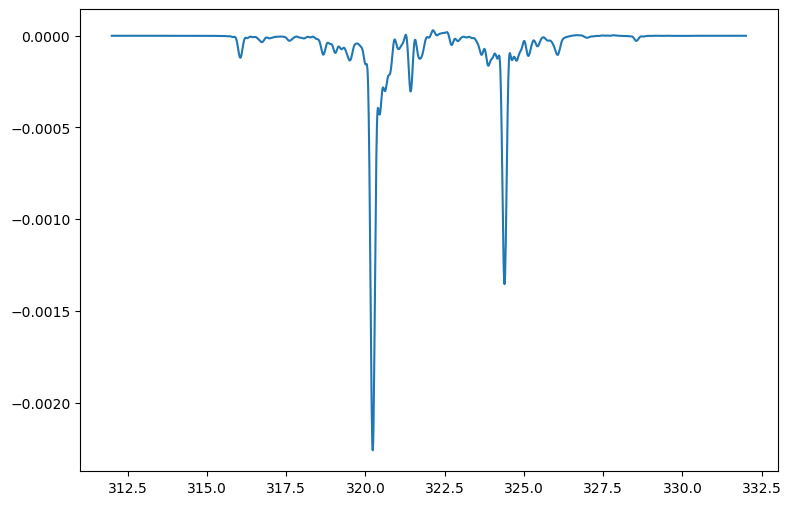

In [13]:
# -----------------------------
# Plot: Drop-port spectra
# -----------------------------
c0 = 299792458
um_scale = 1e-6
freqs_thz = results[0][2] * c0 / um_scale / 1e12  # assuming all freqs arrays identical

plt.figure(figsize=(9,6))
for label, g, freqs, bus, drop, res, tuner in results:
    res_thz = res * c0 / um_scale / 1e12
    plt.plot(freqs_thz, drop, label=label)
    plt.axvline(res_thz, color='k', ls=':', alpha=0.2)

plt.xlabel('Frequency (THz)')
plt.ylabel('Flux at drop port')
plt.title('Effect of tuner gap on drop-port spectra')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Extract data
# -----------------------------
res_freqs_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, res, _) in results]
gaps = [g for (_, g, _, _, _, _, _) in results]

# Separate the "no tuner" case (g=0)
res_no_tuner = None
gaps_filtered = []
res_filtered = []
for g, res in zip(gaps, res_freqs_thz):
    if g == 0:
        res_no_tuner = res
    else:
        gaps_filtered.append(g)
        res_filtered.append(res)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(gaps_filtered, res_filtered, "o-", lw=2, label="With tuner")
if res_no_tuner is not None:
    plt.axhline(res_no_tuner, color="r", ls="--", 
                label=f"No tuner (g=0): {res_no_tuner:.2f} THz")

plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Resonance shift vs tuner gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



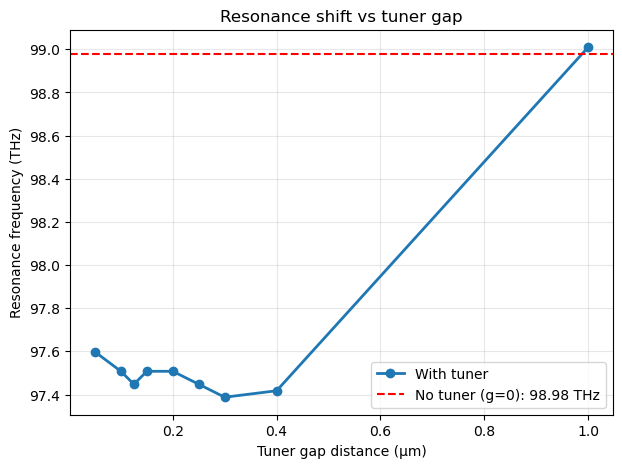

In [13]:
# -----------------------------
# Extract data
# -----------------------------
res_freqs_thz = [res * c0 / um_scale / 1e12 for (_, _, _, _, _, res) in results]
gaps = [g for (_, g, _, _, _, _) in results]

# Separate the "no tuner" case (g=0)
res_no_tuner = None
gaps_filtered = []
res_filtered = []
for g, res in zip(gaps, res_freqs_thz):
    if g == 0:
        res_no_tuner = res
    else:
        gaps_filtered.append(g)
        res_filtered.append(res)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(gaps_filtered, res_filtered, "o-", lw=2, label="With tuner")
if res_no_tuner is not None:
    plt.axhline(res_no_tuner, color="r", ls="--", 
                label=f"No tuner (g=0): {res_no_tuner:.2f} THz")

plt.xlabel("Tuner gap distance (µm)")
plt.ylabel("Resonance frequency (THz)")
plt.title("Resonance shift vs tuner gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
